In [1]:
import pandas as pd
from tqdm import tqdm
import os
import datetime as dt
import sys
import glob

In [2]:
sys.path.append("/data/workspace/libs/pytools")
db_dir = "/data/workspace/Data/DataBase"
from mfrt.research_tools import DBTool

In [3]:
from mfrt.opt_backtest import OptBacktest
from mfrt.eval_netvalue import EvalNetValue
opt_bt=OptBacktest(db_dir)
eval_NV=EvalNetValue(db_dir)

from mfrt.eval_factor import EvalFactor
eval_F = EvalFactor(db_dir)

check_Barra_list=('BETA', 'MOMENTUM', 'SIZE', 'RESVOL', 'BTOP', 'LIQUIDTY',  'SPRET', 'SIZENL', 'GROWTH', 'LEVERAGE')
def test_factor(factor: pd.DataFrame, 
                start_dt, 
                end_dt, 
                display: bool=True, 
                if_trade_tmr: bool=True, 
                specific_return: bool=False,
                Universe=None,
                return_type='Vwap') -> dict:
    F_res=eval_F.quick_test(factor,start_dt=start_dt,end_dt=end_dt,Group_Num=10,Horizon=10,Return_Type=return_type,
                        Specific_Return=specific_return,Universe=Universe,check_Barra_list=check_Barra_list,
                        extraExp_check_dict=None,if_trade_tmr=if_trade_tmr, display=display)
    
    return F_res

In [15]:
df = pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_cls/trained_subspace_heads/trained_fc_prob_H_insample_folds.parquet")
# result = df[
#     (df["method"] == "decay_20d_hl10") & 
#     (df["layer"] == 11) &
#     (df["source_split"] == "test")
# ][["trading_date", "symbol", "factor_value"]]

In [16]:
# df["sum"] = df["sentiment_mean"] * df["n_posts"]
df

symbol,000001,000002,000004,000005,000006,000007,000008,000009,000010,000011,...,688787,688788,688789,688793,688798,688799,688800,688819,688981,689009
date,,,,,,,,,,,,,,,,,,,,,
2020-07-01,0.965603,0.959933,0.929995,0.475970,0.993997,0.948791,0.995035,0.971203,0.477946,0.966573,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-02,0.968060,0.961147,0.489504,0.478415,0.482873,0.476518,0.963044,0.474664,0.485449,0.493522,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-03,0.977069,1.008074,0.973916,0.507005,0.976906,0.979619,0.962816,0.956835,0.482666,0.964109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-06,1.914616,1.952820,1.945009,1.471050,1.932912,1.428127,1.923445,1.940374,1.446473,1.936949,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-07-07,0.935806,0.977026,0.947533,0.983094,0.925239,0.939495,0.965905,0.980011,0.983914,0.973796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,1.824695,1.874267,1.433488,NaN,1.878771,0.467714,1.876832,1.874150,0.936318,1.863578,...,1.865858,1.424998,1.426383,1.399699,1.408305,1.393790,1.874302,1.784330,1.873435,1.904741
2024-05-28,0.937642,0.946112,0.954422,NaN,0.921624,0.502068,0.938012,0.948144,0.934112,0.952770,...,0.950242,0.938189,0.490679,0.945520,0.937836,0.944285,0.931909,0.940036,0.976487,0.933225
2024-05-29,0.953713,0.959451,0.462581,NaN,0.954013,0.462567,0.981101,0.941082,1.016630,0.941899,...,0.962674,0.927895,0.467714,0.923289,0.466269,0.935471,0.944687,0.967909,0.931509,0.955148


In [17]:
# factor_wide = df.set_index(['available_date', 'symbol'])['sum'].unstack()
# factor_wide.index.name = 'date' 

In [18]:
# # 只保留沪深A股：0/3开头(深) + 6开头(沪)，去掉4/8开头(北交所/新三板)
# factor_wide = factor_wide[[c for c in factor_wide.columns if str(c)[0] in '036']]

In [19]:
# factor_wide

In [20]:
import pandas as pd

# 自动添加后缀：6开头加.SH，其他加.SZ
def add_suffix(col_code):
    if str(col_code).startswith('6'):
        return col_code + '.SH'
    else:
        return col_code + '.SZ'

# # factor_wide.index.name = 'date' # 确保行索引有名字
# # factor_wide.columns = [add_suffix(c) for c in factor_wide.columns]

df.index.name = 'date' # 确保行索引有名字
df.columns = [add_suffix(c) for c in df.columns]
print(df.head()) # 检查一下表头是否变成了 000032.SZ
# # print(factor_wide.head()) # 检查一下表头是否变成了 000032.SZ

            000001.SZ  000002.SZ  000004.SZ  000005.SZ  000006.SZ  000007.SZ  \
date                                                                           
2020-07-01   0.965603   0.959933   0.929995   0.475970   0.993997   0.948791   
2020-07-02   0.968060   0.961147   0.489504   0.478415   0.482873   0.476518   
2020-07-03   0.977069   1.008074   0.973916   0.507005   0.976906   0.979619   
2020-07-06   1.914616   1.952820   1.945009   1.471050   1.932912   1.428127   
2020-07-07   0.935806   0.977026   0.947533   0.983094   0.925239   0.939495   

            000008.SZ  000009.SZ  000010.SZ  000011.SZ  ...  688787.SH  \
date                                                    ...              
2020-07-01   0.995035   0.971203   0.477946   0.966573  ...        NaN   
2020-07-02   0.963044   0.474664   0.485449   0.493522  ...        NaN   
2020-07-03   0.962816   0.956835   0.482666   0.964109  ...        NaN   
2020-07-06   1.923445   1.940374   1.446473   1.936949  ...        Na

In [21]:
# pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_baseline/probs_daily/gubapost_probs_20200101.parquet")

In [22]:
# pd.read_parquet("/home/intern_fjq_2026/data/NLP/gubapost/2020/gubapost20200101.parquet")

In [23]:
# 转换为时间戳并升序排列 + 清除 NaT 日期
# factor_wide.index = pd.to_datetime(factor_wide.index, errors='coerce')
# factor_wide = factor_wide[factor_wide.index.notna()]  # 删掉 'None' 等无效日期行
# factor_wide = factor_wide.sort_index()

# print(f"日期范围：{factor_wide.index.min().date()} 到 {factor_wide.index.max().date()}")
# print(f"列数：{len(factor_wide.columns)}")

df.index = pd.to_datetime(df.index, errors='coerce')
df = df[df.index.notna()]  # 删掉 'None' 等无效日期行
df = df.sort_index()

print(f"日期范围：{df.index.min().date()} 到 {df.index.max().date()}")
print(f"列数：{len(df.columns)}")

日期范围：2020-07-01 到 2024-05-31
列数：5243


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,0.07%,0.034,99.0%,43.1%,2.7%,1.05,1.0%,0.62


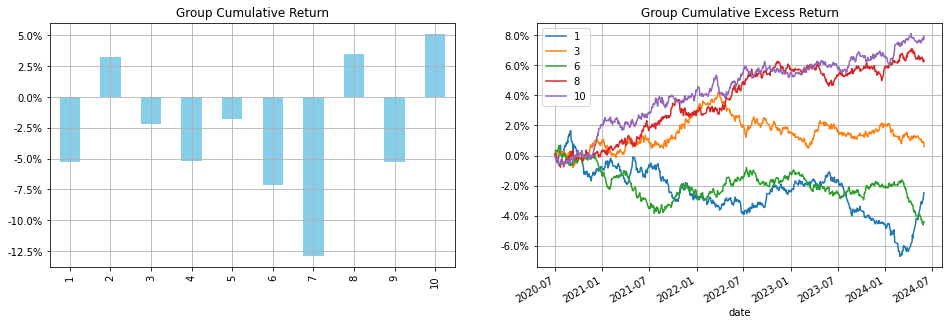

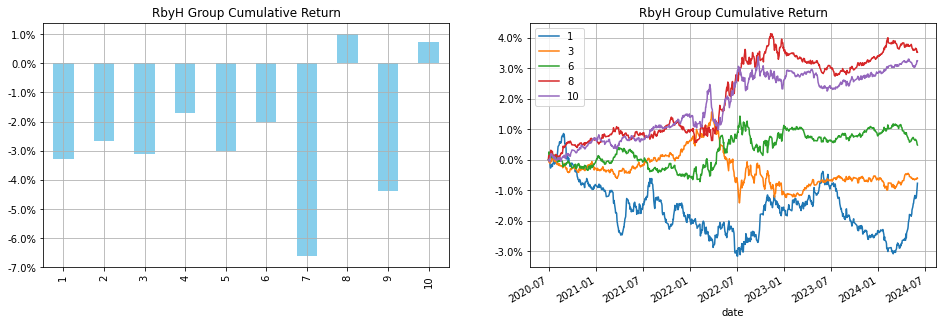

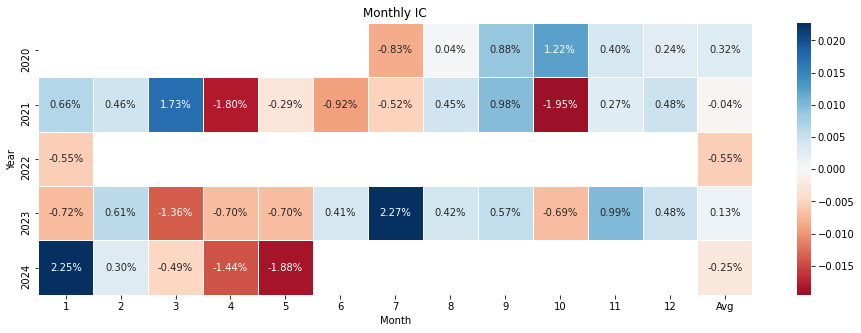

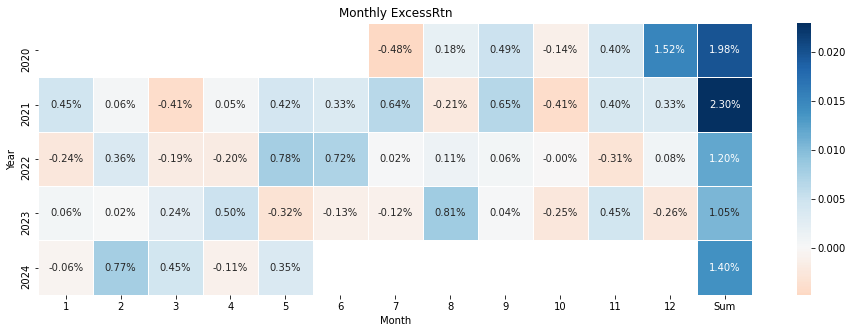

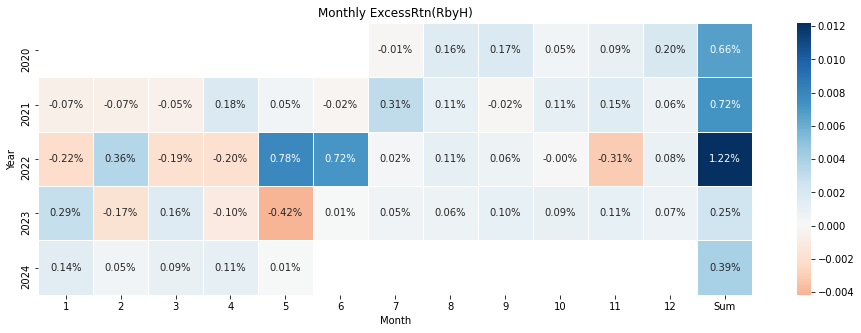

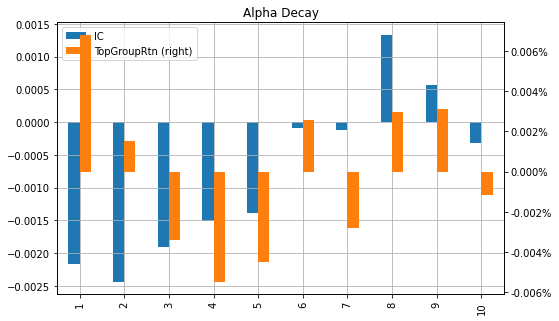

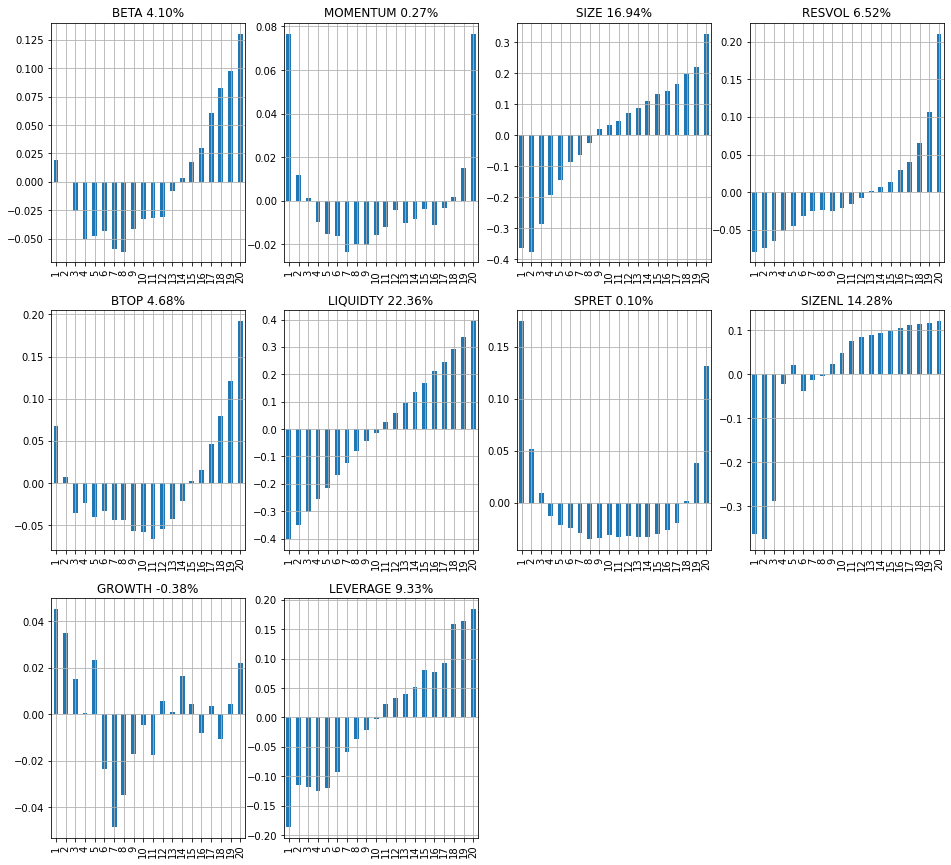

In [25]:
res = test_factor(
            df.dropna(how="all", axis=0),
            start_dt='2020-07-01', 
            end_dt='2024.05.31', 
            if_trade_tmr=True,
            specific_return=True,
            return_type="Vwap",
        )
res